<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Extraction using TSFresh

In [62]:
#import libraries
import pandas as pd
import numpy as np

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
from google.colab import files
df = files.upload()

Saving FitPulse_final_dataset.csv to FitPulse_final_dataset (2).csv


In [76]:
data=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [79]:
display(data.head())

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93


In [80]:
import io
import pandas as pd

# Assuming only one file was uploaded, or you want the first one
# Get the filename and content from the uploaded dictionary
filename = list(df.keys())[0]
file_content = df[filename]

# Read the content into a pandas DataFrame
df = pd.read_csv(io.StringIO(file_content.decode('utf-8')))

print(f"Successfully loaded '{filename}' into a DataFrame.")
display(df.head())

Successfully loaded 'FitPulse_final_dataset (2).csv' into a DataFrame.


,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93


In [83]:
# Ensure timestamp
df['timestamp'] = pd.to_datetime(df['time_stamp'])

In [84]:
WINDOW_SIZE = 10    # number of rows per window
STEP_SIZE = 10      # overlap

rows = []
window_id = 0

for start in range(0, len(df) - WINDOW_SIZE, STEP_SIZE):
    window = df.iloc[start:start + WINDOW_SIZE].copy()
    window["id"] = window_id
    rows.append(window)
    window_id += 1

df_windowed = pd.concat(rows)


In [102]:
# Rename for tsfresh
ts_df = df[['Patient_ID', 'time_stamp', 'resting_heart_rate']]
ts_df.columns = ['id', 'time', 'value'
]

In [103]:
# Safety cleaning
ts_df.replace([np.inf, -np.inf], np.nan, inplace=True)
ts_df.dropna(inplace=True)

#If infinity / NaN exists → TSFresh WILL FAIL.

In [105]:
df['Patient_ID'].value_counts()

,count
Patient_ID,
P0892,2
P5790,1
P5789,1
P5786,1
P5785,1
...,...
P2893,1
P2892,1
P2891,1


In [106]:
from tsfresh import extract_features

features = extract_features(
    ts_df,
    column_id='id',
    column_sort='time'
)

features = features.fillna(0)

Feature Extraction: 100%|██████████| 7908/7908 [12:13<00:00, 10.78it/s]


In [107]:
features

,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
P0001,0.0,0.0,0.0,0.0,72.0,5184.0,0.0,0.0,0.0,72.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P0002,0.0,0.0,0.0,0.0,86.0,7396.0,0.0,0.0,0.0,86.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P0003,0.0,0.0,0.0,0.0,63.0,3969.0,0.0,0.0,0.0,63.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P0005,0.0,0.0,0.0,0.0,91.0,8281.0,0.0,0.0,0.0,91.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P0006,0.0,0.0,0.0,0.0,93.0,8649.0,0.0,0.0,0.0,93.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P8667,0.0,0.0,0.0,0.0,92.0,8464.0,0.0,0.0,0.0,92.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P8668,0.0,0.0,0.0,0.0,87.0,7569.0,0.0,0.0,0.0,87.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P8669,0.0,0.0,0.0,0.0,97.0,9409.0,0.0,0.0,0.0,97.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P8670,0.0,0.0,0.0,0.0,67.0,4489.0,0.0,0.0,0.0,67.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.05, #5%
    random_state=42
)

features_filled = features.fillna(0)

anomaly_labels = model.fit_predict(features_filled)

features['anomaly'] = anomaly_labels

In [109]:
features['anomaly'].value_counts()

,count
anomaly,
1,7517
-1,391


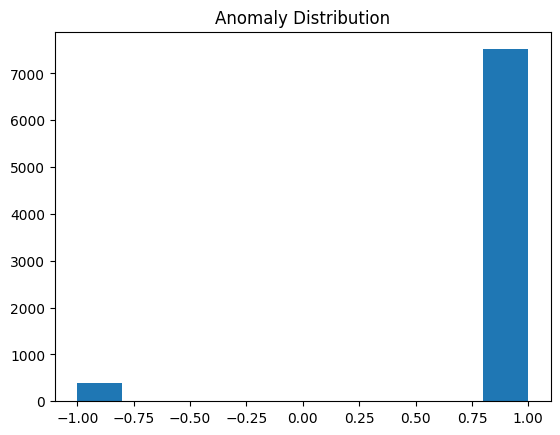

In [110]:
import matplotlib.pyplot as plt

plt.hist(anomaly_labels)
plt.title("Anomaly Distribution")
plt.show()

In [111]:
df.columns

Index(['Patient_ID', 'heart_rate', 'step_count', 'sleep_tracking',
       'time_stamp', 'Weight', 'Height', 'gender', 'age', 'daily_calories',
       'daily_sleep_hours', 'daily_steps', 'resting_heart_rate', 'timestamp'],
      dtype='object')

In [114]:
sensor_columns = ['resting_heart_rate', 'daily_steps', 'daily_sleep_hours']

long_df = df_windowed.melt(
    id_vars=['id', 'timestamp'],
    value_vars=sensor_columns,
    var_name='kind',
    value_name='value'
)

long_df.rename(columns={
    'timestamp': 'time'
}, inplace=True)

long_df.replace([np.inf, -np.inf], np.nan, inplace=True)
long_df.dropna(inplace=True)

In [115]:
from tsfresh import extract_features

features = extract_features(
    long_df,
    column_id='id',
    column_sort='time',
    column_kind='kind',
    column_value='value'
)

features = features.fillna(0)
features.head()

Feature Extraction: 100%|██████████| 2370/2370 [04:19<00:00,  9.14it/s]


,daily_sleep_hours__variance_larger_than_standard_deviation,daily_sleep_hours__has_duplicate_max,daily_sleep_hours__has_duplicate_min,daily_sleep_hours__has_duplicate,daily_sleep_hours__sum_values,daily_sleep_hours__abs_energy,daily_sleep_hours__mean_abs_change,daily_sleep_hours__mean_change,daily_sleep_hours__mean_second_derivative_central,daily_sleep_hours__median,...,resting_heart_rate__fourier_entropy__bins_5,resting_heart_rate__fourier_entropy__bins_10,resting_heart_rate__fourier_entropy__bins_100,resting_heart_rate__permutation_entropy__dimension_3__tau_1,resting_heart_rate__permutation_entropy__dimension_4__tau_1,resting_heart_rate__permutation_entropy__dimension_5__tau_1,resting_heart_rate__permutation_entropy__dimension_6__tau_1,resting_heart_rate__permutation_entropy__dimension_7__tau_1,resting_heart_rate__query_similarity_count__query_None__threshold_0.0,resting_heart_rate__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.0,0.0,1.0,83.5,701.31,0.600000,-0.066667,0.11250,8.35,...,0.867563,0.867563,1.791759,1.494175,1.945910,1.791759,1.609438,1.386294,0.0,89.000000
1,0.0,0.0,1.0,1.0,80.6,653.52,0.800000,0.044444,0.08750,8.15,...,0.867563,1.242453,1.791759,1.255482,1.747868,1.791759,1.609438,1.386294,0.0,75.857143
2,0.0,0.0,0.0,1.0,78.7,622.29,0.744444,-0.055556,-0.06875,7.90,...,1.329661,1.560710,1.791759,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,84.285714
3,0.0,0.0,0.0,1.0,81.8,672.62,0.688889,-0.022222,0.04375,8.20,...,1.011404,1.011404,1.560710,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,88.142857
4,0.0,0.0,0.0,1.0,79.0,627.60,0.777778,0.133333,-0.10000,7.95,...,1.011404,1.329661,1.791759,1.559581,1.747868,1.791759,1.609438,1.386294,0.0,81.000000


In [116]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
labels = model.fit_predict(features)

features['anomaly'] = labels


In [119]:
df['anomaly'] = 1

for wid in features.query("anomaly == -1").index:
    df.loc[wid:wid+WINDOW_SIZE-1, 'anomaly'] = -1

In [120]:
df['anomaly'].value_counts()

,count
anomaly,
1,7599
-1,310


In [122]:
import plotly.express as px
import pandas as pd

df_plot = pd.DataFrame({ "Anomaly Label": anomaly_labels })

fig = px.histogram(
    df_plot,
    x="Anomaly Label",
    nbins=2,
    title="Anomaly Distribution"
)

# Replace -1 / 1 with readable labels
fig.update_xaxes(
    tickvals=[-1, 1],
    ticktext=["Anomaly", "Normal"]
)

fig.update_yaxes(title="Count")

fig.show()

Clean data with _clean_for_tsfresh

Extract TSFresh features with extract_tsfresh_features

Auto-select top features with auto_select_features

In [127]:
df_clean = clean_for_tsfresh(df)
print("\nCleaned DataFrame:")
print(df_clean)


Cleaned DataFrame:
Empty DataFrame
Columns: [Patient_ID, heart_rate, step_count, sleep_tracking, time_stamp, Weight, Height, gender, age, daily_calories, daily_sleep_hours, daily_steps, resting_heart_rate, timestamp, anomaly]
Index: []


In [126]:
import numpy as np
import pandas as pd

def clean_for_tsfresh(df):
    """
    Cleans a DataFrame by replacing infinite values with NaN and then dropping
    rows with NaN values, preparing it for TSFresh feature extraction.

    Parameters:
    df (pd.DataFrame): The input DataFrame.

    Returns:
    pd.DataFrame: The cleaned DataFrame.
    """
    cleaned_df = df.replace([np.inf, -np.inf], np.nan)
    cleaned_df.dropna(inplace=True)
    return cleaned_df

print("The 'clean_for_tsfresh' function has been defined.")

The 'clean_for_tsfresh' function has been defined.


In [128]:
features

,daily_sleep_hours__variance_larger_than_standard_deviation,daily_sleep_hours__has_duplicate_max,daily_sleep_hours__has_duplicate_min,daily_sleep_hours__has_duplicate,daily_sleep_hours__sum_values,daily_sleep_hours__abs_energy,daily_sleep_hours__mean_abs_change,daily_sleep_hours__mean_change,daily_sleep_hours__mean_second_derivative_central,daily_sleep_hours__median,...,resting_heart_rate__fourier_entropy__bins_10,resting_heart_rate__fourier_entropy__bins_100,resting_heart_rate__permutation_entropy__dimension_3__tau_1,resting_heart_rate__permutation_entropy__dimension_4__tau_1,resting_heart_rate__permutation_entropy__dimension_5__tau_1,resting_heart_rate__permutation_entropy__dimension_6__tau_1,resting_heart_rate__permutation_entropy__dimension_7__tau_1,resting_heart_rate__query_similarity_count__query_None__threshold_0.0,resting_heart_rate__mean_n_absolute_max__number_of_maxima_7,anomaly
0,0.0,0.0,0.0,1.0,83.5,701.31,0.600000,-0.066667,1.125000e-01,8.35,...,0.867563,1.791759,1.494175,1.945910,1.791759,1.609438,1.386294,0.0,89.000000,1
1,0.0,0.0,1.0,1.0,80.6,653.52,0.800000,0.044444,8.750000e-02,8.15,...,1.242453,1.791759,1.255482,1.747868,1.791759,1.609438,1.386294,0.0,75.857143,1
2,0.0,0.0,0.0,1.0,78.7,622.29,0.744444,-0.055556,-6.875000e-02,7.90,...,1.560710,1.791759,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,84.285714,1
3,0.0,0.0,0.0,1.0,81.8,672.62,0.688889,-0.022222,4.375000e-02,8.20,...,1.011404,1.560710,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,88.142857,1
4,0.0,0.0,0.0,1.0,79.0,627.60,0.777778,0.133333,-1.000000e-01,7.95,...,1.329661,1.791759,1.559581,1.747868,1.791759,1.609438,1.386294,0.0,81.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785,0.0,0.0,0.0,1.0,79.1,628.13,0.655556,-0.122222,-7.500000e-02,8.15,...,0.867563,1.791759,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,84.571429,1
786,0.0,0.0,0.0,1.0,78.3,615.55,0.677778,0.033333,-5.625000e-02,7.65,...,1.791759,1.791759,1.494175,1.945910,1.791759,1.609438,1.386294,0.0,84.142857,1
787,0.0,0.0,0.0,1.0,80.0,646.90,1.000000,-0.044444,7.500000e-02,7.85,...,0.867563,1.560710,1.732868,1.945910,1.791759,1.609438,1.386294,0.0,84.857143,1
788,0.0,0.0,0.0,1.0,80.4,648.98,0.722222,-0.011111,1.125000e-01,8.15,...,1.242453,1.791759,0.900256,1.277034,1.560710,1.609438,1.386294,0.0,86.285714,1


In [131]:
metric_data_cols = []
for canonical, aliases in METRIC_ALIASES.items():
    for col in df.columns:
        if col.lower() in aliases:
            metric_data_cols.append(col)
            break # Found a match for this canonical metric

if metric_data_cols:
    print("Displaying data for identified metric columns in 'df' DataFrame:")
    display(df[metric_data_cols].head())
else:
    print("No metric columns (heart_rate, sleep_duration, step_count) found in the 'df' DataFrame based on METRIC_ALIASES.")

Displaying data for identified metric columns in 'df' DataFrame:


,heart_rate,step_count
0,74.499653,26.0
1,90.833116,6.0
2,61.270774,40.0
3,59.807869,29.0
4,92.702179,34.0


In [132]:
features.to_csv("tsfresh_features.csv")
files.download("tsfresh_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>